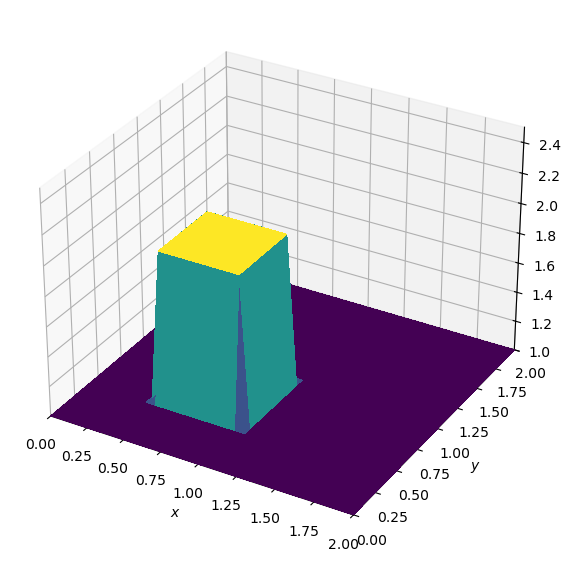

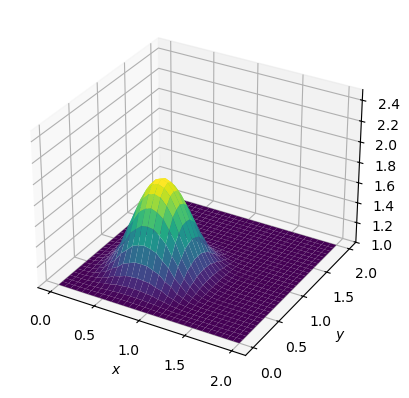

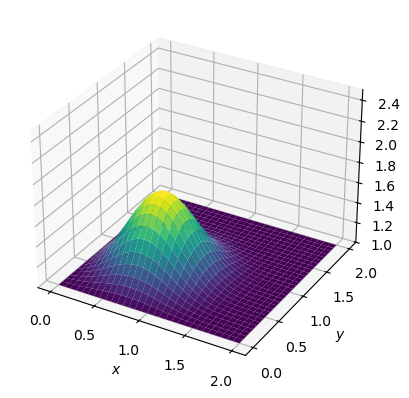

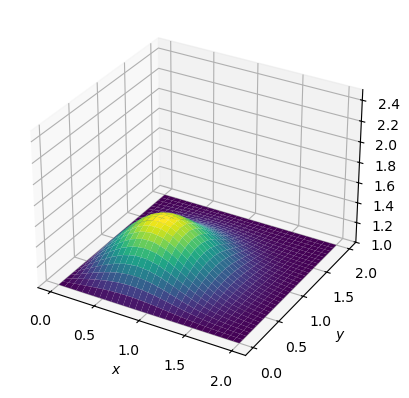

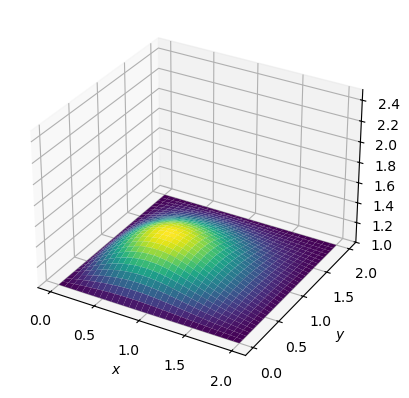

In [10]:
import numpy
from matplotlib import pyplot, cm
from mpl_toolkits.mplot3d import Axes3D ##library for 3d projection plots

nx = 31
ny = 31
nt = 17
nu = 0.05
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = 0.25         # σ≤0.25
dt = sigma * dx * dy / nu  # 傅里叶模态分析 p138

x = numpy.linspace(0, 2, nx)
y = numpy.linspace(0, 2, ny)

u = numpy.ones((ny, nx))
un = numpy.ones((ny, nx))

u[int(0.5 / dy):int(1 / dy + 1),int(0.5 / dx):int(1 / dx + 1)] = 2

fig, ax = pyplot.subplots(figsize=(11, 7), dpi=100, subplot_kw=dict(projection='3d'))
X, Y = numpy.meshgrid(x, y)

surf = ax.plot_surface(X, Y, u, rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False)

ax.set_xlim(0, 2)
ax.set_xlim (0, 2 ) 
ax.set_ylim(0, 2)
ax.set_zlim(1, 2.5)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$');

	
###Run through nt timesteps

def diffuse(nt):
    u[int(0.5 / dy):int(1 / dy + 1),int(0.5 / dx):int(1 / dx + 1)] = 2

    for n in range(nt + 1):
        un = u.copy()
        u[1:-1, 1:-1] = (un[1:-1, 1:-1] +   # [i, j] = un[1:-1, 1:-1] 去掉边界
                        nu * dt / dx**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                        nu * dt / dy**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1]))

        u[0, :] = 1
        u[-1, :] = 1
        u[:, 0] = 1
        u[:, -1] = 1

    fig, ax = pyplot.subplots(subplot_kw=dict(projection='3d'))
    surf = ax.plot_surface(X, Y, u, rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=True)

    ax.set_zlim(1, 2.5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$');

diffuse(10)
diffuse(20)
diffuse(50)
diffuse(90)